In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2023-10-06 12:52:32.735974: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Tensorflow not install, you could not use those pipelines
To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [2]:
from moabb.paradigms import P300
from moabb.datasets import BNCI2014_008, BNCI2014_009, EPFLP300
plt.style.use('default')

fmax=16
sfreq=32 
paradigm = P300(resample=sfreq, tmin=-0.2, tmax=1.0, fmin=0.5, fmax=fmax)
dataset = BNCI2014_009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)


Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/data/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/paradigms/base.py:346: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from mne.decoding import Scaler
import scipy.linalg

X = epochs.get_data()
y = labels

def hankel_tensor(X, y=None):    
    n_times = X.shape[-1]
    half = n_times//2
    hankel_nopad = lambda x: scipy.linalg.hankel(x[:half],x[half:half*2])
    return np.apply_along_axis(hankel_nopad,-1, X)
    

X = hankel_tensor(X)
X.shape


(1728, 16, 19, 19)

In [10]:
from hoda.hoda import HODA, mode_scatter, center, mode_scatter
from hoda.tenalg import trunc_eigh, lanczos, pinvh


hoda = HODA(
            rank=[1,1,1],
            max_iter=32,
            tol=0,
            init ='svd',
            shrinkage=('lw','lw','lw'),
            toeplitz=(1,2),
            obj='rt',
            solver='lanczos',
            taper=False,
            keep_train_info=True,
            verbose=True,
            lasso=False,
            prune=False
        )
%lprun -f hoda.fit hoda.fit(X,y)

Initializing factors...
Fitting discriminative tucker model...


  0%|          | 0/32 [00:00<?, ?it/s]

Fitted tucker model of rank [1, 1, 1] ...


Timer unit: 1e-09 s

Total time: 17.3214 s
File: /data/Workspace/PhD/hoda-bci/hoda/hoda.py
Function: fit at line 201

Line #      Hits         Time  Per Hit   % Time  Line Contents
   201                                               def fit(self, X, y):
   202                                                   # Setup
   203         1   24754952.0    2e+07      0.1          X = tl.tensor(X.copy(), dtype=X.dtype)
   204         1     226823.0 226823.0      0.0          self.classes_, class_counts = np.unique(y, return_counts=True)
   205         1       8472.0   8472.0      0.0          class_counts = tl.tensor(class_counts)
   206         1       2449.0   2449.0      0.0          n_samples, *shape = X.shape
   207         1        344.0    344.0      0.0          order = len(shape)
   208         1        401.0    401.0      0.0          if self.rank is None:
   209                                                       self.rank_ = shape.copy()
   210                                   

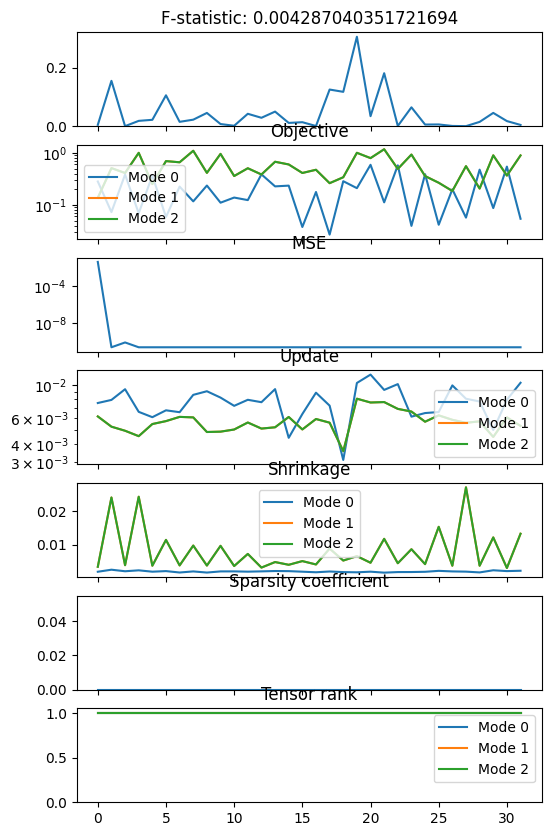

In [11]:
label = [f'Mode {k}' for k in range(len(X.shape)-1)]
if hoda.keep_train_info:
    fig, axs = plt.subplots(7,1, sharex=True, figsize=(6,10))

    axs[0].set_title(f"F-statistic: {hoda.train_info_['f_stat'][-1]}")
    axs[0].plot(hoda.train_info_["f_stat"])
    axs[0].set_ylim([0,None])

    axs[1].set_title('Objective')
    axs[1].semilogy(np.asarray(hoda.train_info_["mode_objective"]).T, label=label)
    axs[1].legend()

    axs[2].set_title('MSE')
    axs[2].semilogy(hoda.train_info_["mse"])

    axs[3].set_title('Update')
    axs[3].semilogy(tl.to_numpy(tl.tensor(hoda.train_info_["mode_update"])).T, label=label)
    axs[3].legend()

    axs[4].set_title('Shrinkage')
    axs[4].plot(tl.to_numpy(tl.tensor(hoda.train_info_["mode_shrinkage"])).T, label=label)
    axs[4].legend()
    
    axs[5].set_title('Sparsity coefficient')
    axs[5].plot(tl.to_numpy(tl.tensor([l for l in hoda.train_info_['lambd']])))
    axs[5].set_ylim([0,None])


    axs[6].set_title('Tensor rank')
    axs[6].plot(tl.to_numpy(tl.tensor(hoda.train_info_["mode_rank"])).T, label=label)
    axs[6].set_ylim([0,None])
    axs[6].legend()

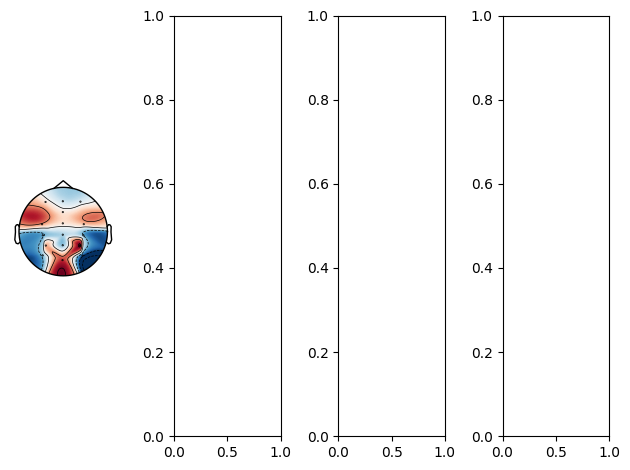

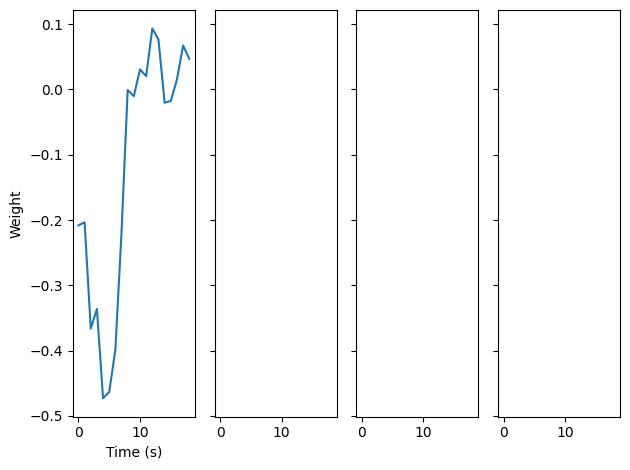

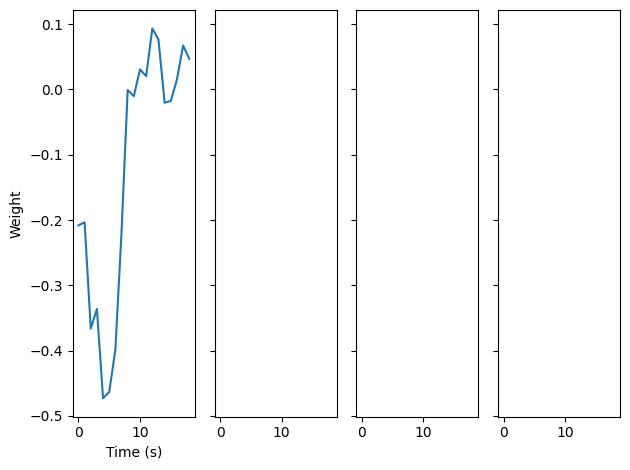

In [12]:
col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[1]):
    w = tl.to_numpy(hoda.scalings_[1][:,i])
    axs.flatten()[i].plot(w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');

n_row = int( np.ceil(hoda.rank_[2] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[2]):
    w = tl.to_numpy(hoda.scalings_[2][:,i])
    axs.flatten()[i].plot(w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


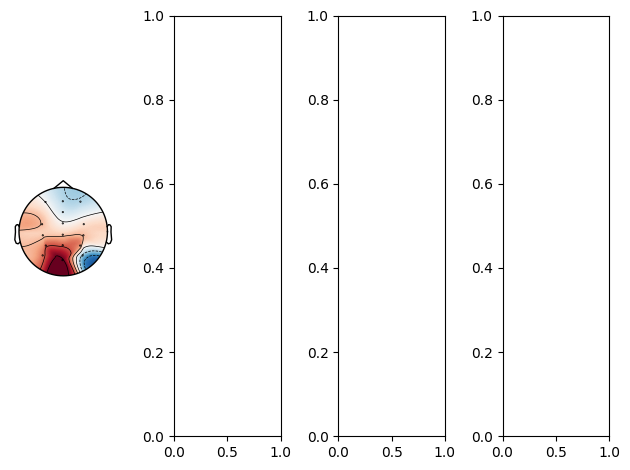

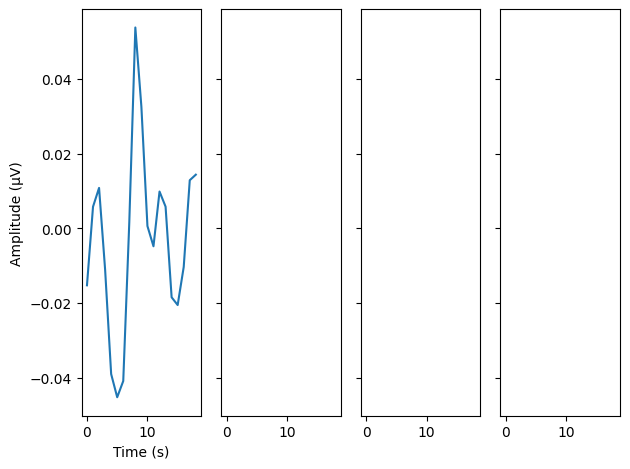

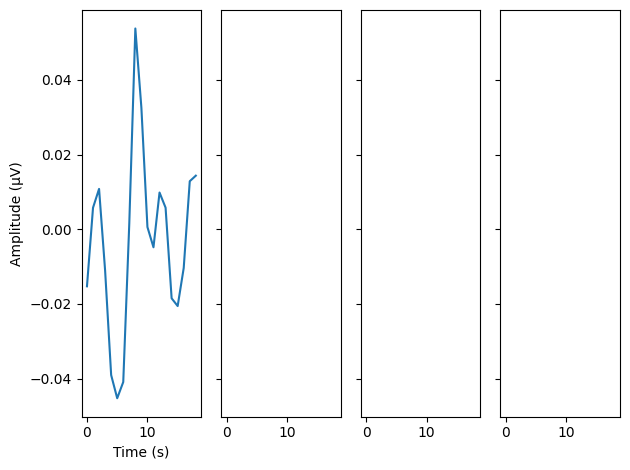

In [13]:
n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_[1]):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot( a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude (µV)');

n_row = int(np.ceil(hoda.rank_[2] / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[2]
for i in range(hoda.rank_[2]):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude (µV)');

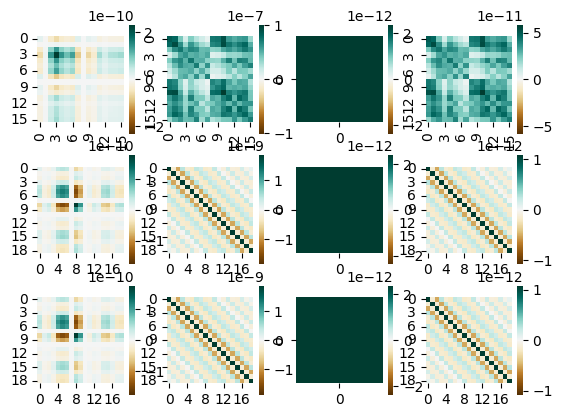

In [14]:
_, axs = plt.subplots(3,4,)
for k in range(3):
    
    scatter_b = tl.to_numpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[k,0].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,0])    
    
    scatter_w = tl.to_numpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,1])    
    axs[k,1].set_aspect('equal')


    cov_l= tl.to_numpy(hoda.cov_l_[k])
    vmax = np.max(np.abs(cov_l))
    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,2])    
    axs[k,2].set_aspect('equal')


    cov_w=  tl.to_numpy(hoda.cov_w_[k])
    vmax = np.max(np.abs(cov_w))
    sns.heatmap(cov_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,3])    
    axs[k,3].set_aspect('equal')

0.5402247299382716


/data/.virtualenvs/hoda/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


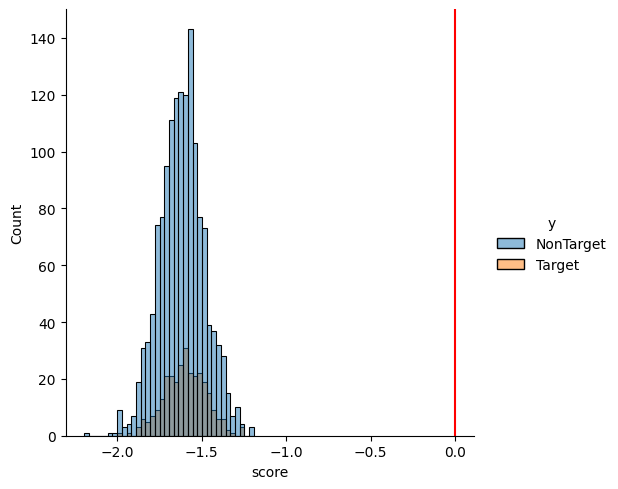

In [15]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
import pandas as pd

Xt = hoda.transform(X)
Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0],-1)))
lda = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr') 
lda.fit(Xt_flat, y)
score_pred = lda.decision_function(Xt_flat)
df = pd.DataFrame(dict(score=score_pred,y=y))
sns.displot(df, x='score', hue='y')
plt.axvline(0, color='red')
print(roc_auc_score(y,score_pred))